In [ ]:
import pandas as pd
import numpy as np


from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn import tree

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:


df = pd.read_csv('insurance.csv')

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df = df.drop_duplicates().reset_index(drop=True)

feature_cols = ["age", "bmi", "children", "sex", "smoker", "region"]
X = pd.get_dummies(df[feature_cols], columns=["sex", "smoker", "region"], dtype=int)
y = df["charges"].copy()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
dt = DecisionTreeRegressor(random_state=42)

In [10]:
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [11]:
y_pred = dt.predict(X_test)

In [12]:
train_score = dt.score(X_train, y_train)
test_score = dt.score(X_test, y_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Training R^2:", round(train_score, 4))
print("Test R^2:", round(test_score, 4))
print("MAE:", round(mae, 2))
print("R^2:", round(r2, 4))

Training R^2: 1.0
Test R^2: 0.7981
MAE: 2757.52
R^2: 0.7981


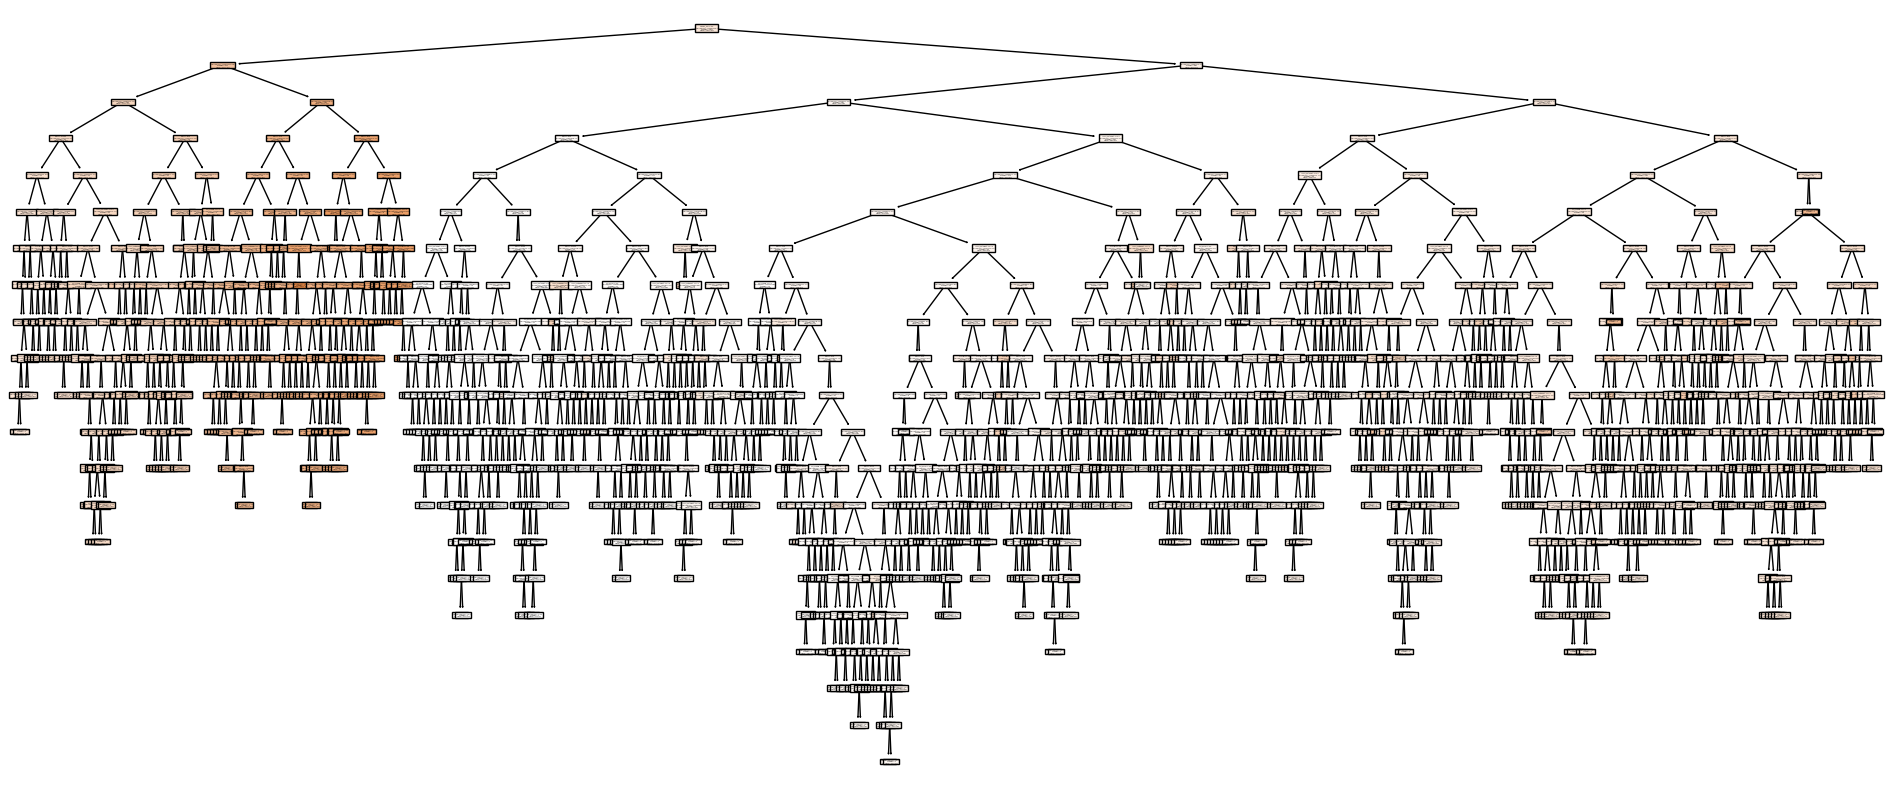

In [13]:
plt.figure(figsize=(24, 10))
tree.plot_tree(
    dt,
    filled=True,
    feature_names=list(X.columns),
)
plt.show()

In [14]:
import pickle
pickle.dump(dt,open("model1.pkl","wb"))